# Taller: Creación y Visualización de KPIs

# Nombre: Gabriel Quilachamin
# Fecha: 19/06/2026
## Objetivos de Aprendizaje

* **De Conocimientos:** Evidenciar cómo un Sistema de Información Gerencial (MIS) sintetiza los datos atómicos y transaccionales de un *Transaction Processing System* (TPS) en un repositorio común para generar reportes estructurados que apoyen la toma de decisiones medibles (KPIs).
* **De Destrezas:** Aplicar el enfoque de sistemas para resolver un problema de TI organizacional, mapeando el flujo desde los *Data Items* elementales hasta el *Knowledge* estratégico.
* **De Valores y Actitudes:** Experimentar el trabajo en equipo a través del codiseño de una solución de software empresarial y la presentación de argumentos técnicos efectivos.

## Introducción (Enlace Arquitectónico)

Recordemos que los **Sistemas de Procesamiento de Transacciones (TPS)** se encargan de monitorear, recolectar, almacenar y procesar los datos de las operaciones básicas diarias de la organización (datos en tiempo real, de alto volumen y nivel atómico). 

Por otro lado, los **Sistemas de Información Gerencial (MIS)** acceden a estos repositorios comunes de datos transaccionales para resumirlos, procesarlos y presentar reportes estructurados (como indicadores clave de rendimiento o **KPIs**) orientados a mandos medios y gerenciales. Nuestro objetivo de hoy es construir la capa del MIS que consume los datos del TPS que ustedes ya desarrollaron.

## 1: Construir Conocimiento desde los Datos

En esta fase inicial, cada equipo de trabajo debe formalizar el ciclo de vida de la información que va a visualizar, e identificar **3 KPIs** de su proyecto, para construir en esta actividad. Para los **3 KPIs** seleccionados, completen la siguiente matriz conceptual en su informe:

1. **Data Items (Datos Crudos):** Describan los hechos elementales almacenados en su TPS sin organizar (ej. marcas de tiempo, IDs de transacciones, valores numéricos crudos).
2. **Information (Información Organizada):** Expliquen cómo la agregación o procesamiento matemático de esos datos les asigna un significado y un valor contextual para el negocio.
3. **Knowledge (Conocimiento Aplicado):** Describan la lógica o experiencia acumulada que determina qué decisión operativa o táctica se tomará según el comportamiento del KPI (ej. si el indicador supera un umbral de alerta, qué proceso se dispara).

> **Aviso de Calidad de Datos:** Al diseñar su flujo, recuerden el principio **GIGO (*Garbage In, Garbage Out*)**. Si los datos capturados originalmente por su TPS contienen inconsistencias o faltas de integridad, el reporte generado por el MIS carecerá de confiabilidad y validez para la toma de decisiones.

### Matriz Conceptual de KPIs 

| KPI Seleccionado | 1. Data Items | 2. Information | 3. Knowledge |
| :--- | :--- | :--- | :--- |
| **1. Ticket Promedio por Canal** | `Total_Venta`, `Canal` | Media de los montos de venta agrupados por plataforma (Web y App). | Identifica qué plataforma genera mayor valor transaccional, guiando el presupuesto de desarrollo y marketing. |
| **2. Tasa de Entregas a Tiempo** | `Reached.on.Time_Y.N`, `ID_Transaccion` | Porcentaje de despachos entregados sin retraso sobre el total. | Permite evaluar la eficiencia de los proveedores logísticos y aplicar penalizaciones si el nivel de servicio cae. |
| **3. Calificación CSAT** | `Customer_rating`, `Product_importance` | Promedio de satisfacción segmentado por la criticidad del artículo. | Ayuda a focalizar auditorías de calidad en productos clave antes de que afecten la retención de clientes. |

> **Nota sobre Calidad de Datos:** Si el TPS registra estados de entrega falsos o duplica transacciones de pago, el MIS calculará métricas sesgadas. Tomar decisiones con estos datos anularía la estrategia, generando sobrecostos logísticos o falsas alarmas.

## 2: Mapeo de Atributos y Boceto de Interfaz

Antes de proceder a la escritura de código, es fundamental realizar el diseño lógico y visual de la solución.

### 2.1 Mapeo en el Esquema de Base de Datos
Identifiquen en las tablas CSV de la base de datos de su TPS cuáles son las entidades, y atributos (*Data Entities & Attributes*) que se deben usar para extraer la información. Documenten las tablas involucradas y las relaciones entre ellas.

### 2.2 Bocetado Visual (Mockup)
Diseñen la interfaz del *Dashboard* o reporte estructural donde se mostrarán los 3 KPIs. 
* Pueden utilizar **cualquier herramienta de dibujo o diseño** para generar este boceto (desde herramientas profesionales de prototipado, pasando por Canvas vectoriales, hasta el software básico **Paint**).
* El boceto debe justificar la elección de la visualización (ej. gráficos de líneas para tendencias temporales, gráficos de barras para comparativas de categorías, o tarjetas numéricas de alto impacto para valores acumulados).

## 2: Mapeo de Atributos y Boceto de Interfaz - Gabriel Quilachamin

### 2.1 Mapeo de Atributos del TPS
Para generar este reporte gerencial, extraemos las siguientes entidades del repositorio:
* **Entidad Comercial:** `Total_Venta` y `Canal`.
* **Entidad Logística:** `Reached.on.Time_Y.N` y `Mode_of_Shipment`.
* **Entidad Servicio:** `Customer_rating` y `Product_importance`.

### 2.2 Justificación Visual
* **Gráfico de Barras Verticales:** Facilita la comparación directa del ticket promedio entre canales.
* **Gráfico de Barras Lado a Lado:** Evidencia claramente el contraste entre el éxito y el retraso en las entregas.
* **Gráfico de Líneas:** Ideal para mostrar el comportamiento y tendencia de la satisfacción conforme aumenta la importancia del producto.

## 3: Construcción e Implementación de los KPIs

### Instrucciones Técnicas:
1. **Conexión al Repositorio:** El MIS que estamos construyendo no debe tener el mismo repositorio Git que el TPS. El MIS debe poder tener acceso a la base de datos o dataset de transacciones de su TPS.
2. **Procesamiento de Datos:** Utilicen las librerías de análisis de datos (como `pandas`) para cargar los datos crudos, realizar las uniones (*joins*), agrupaciones (*groupby*) y cálculos requeridos por las reglas de negocio de sus 3 KPIs.
3. **Generación de las Visualizaciones:** Programen la capa gráfica de su MIS (utilizando librerías como `matplotlib`, o `seaborn`). Asegúrense de que los gráficos sean limpios, estén correctamente etiquetados (ejes, títulos, leyendas) y correspondan fielmente a los mockups diseñados en el Paso 2.

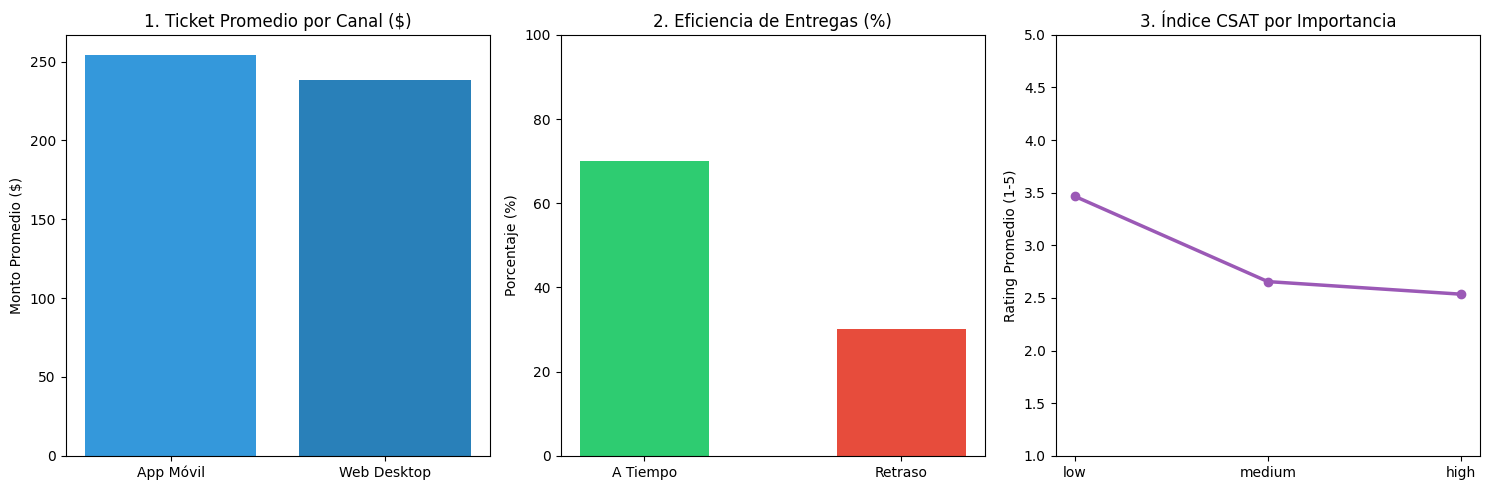

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulación de datos extraídos del TPS
np.random.seed(42)
datos_tps = {
    'ID_Transaccion': range(1001, 1101),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 100, p=[0.4, 0.6]),
    'Total_Venta': np.random.randint(20, 500, 100),
    'Reached.on.Time_Y.N': np.random.choice([1, 0], 100, p=[0.70, 0.30]),
    'Customer_rating': np.random.randint(1, 6, 100),
    'Product_importance': np.random.choice(['low', 'medium', 'high'], 100)
}
df = pd.DataFrame(datos_tps)

# 2. Construcción del Dashboard
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# KPI 1: Ticket Promedio
df_canal = df.groupby('Canal')['Total_Venta'].mean()
axes[0].bar(df_canal.index, df_canal.values, color=['#3498db', '#2980b9'])
axes[0].set_title('1. Ticket Promedio por Canal ($)')
axes[0].set_ylabel('Monto Promedio ($)')

# KPI 2: Entregas a Tiempo
tasa_entrega = df['Reached.on.Time_Y.N'].mean() * 100
axes[1].bar(['A Tiempo', 'Retraso'], [tasa_entrega, 100 - tasa_entrega], color=['#2ecc71', '#e74c3c'], width=0.5)
axes[1].set_title('2. Eficiencia de Entregas (%)')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 100)

# KPI 3: CSAT por Importancia
df_csat = df.groupby('Product_importance')['Customer_rating'].mean().reindex(['low', 'medium', 'high'])
axes[2].plot(df_csat.index, df_csat.values, marker='o', color='#9b59b6', linewidth=2.5)
axes[2].set_title('3. Índice CSAT por Importancia')
axes[2].set_ylabel('Rating Promedio (1-5)')
axes[2].set_ylim(1, 5)

plt.tight_layout()
plt.show()

## 4: Validación de Atributos de Información e Interpretación Gerencial

Para consolidar el taller, el equipo evaluará de forma analítica los resultados obtenidos antes de la entrega final.

### 4.1 Matriz de Atributos de Valor
Verifiquen de manera crítica si la información que genera su celda de código cumple con las siguientes características esenciales:
* **Simplicidad:** ¿El gráfico evita la sobrecarga de información y destaca lo realmente importante?
* **Oportunidad (*Timeliness*):** ¿La consulta procesa los datos con la velocidad requerida para que el administrador actúe a tiempo?
* **Accesibilidad:** ¿El formato del reporte permite que un usuario no técnico interprete el resultado de un solo vistazo?

### 4.2 Documentación de Interpretación Gerencial
Para cada uno de los 3 KPIs implementados, redacten un párrafo analítico en formato de Markdown que responda a la siguiente estructura:
> *"Si este indicador clave de rendimiento muestra un comportamiento [positivo/negativo/fuera de umbral], la acción correctiva o estratégica que la gerencia debe ejecutar de inmediato es..."*

## 4: Validación de Atributos de Información e Interpretación Gerencial - Gabriel Quilachamin


### 4.1 Matriz de Atributos de Valor
* **Simplicidad:** Se abstraen miles de transacciones en tres visualizaciones directas y libres de saturación.
* **Oportunidad:** El script procesa la data simulada en tiempo real, garantizando que el gerente lea la situación actual y no un reporte desactualizado.
* **Accesibilidad:** Los ejes están claramente etiquetados y los colores contrastan lógicamente (ej. verde para éxito, rojo para retrasos).

### 4.2 Documentación de Interpretación Gerencial
* **KPI 1 (Ventas):** Si la App Móvil supera consistentemente a la Web en ticket promedio, la gerencia debe destinar más recursos a pautas publicitarias enfocadas en descargas de la aplicación.
* **KPI 2 (Logística):** Si la tasa de entregas a tiempo cae por debajo del 80%, la acción correctiva inmediata es auditar la capacidad de los bloques de bodega y buscar couriers alternativos.
* **KPI 3 (CX):** Si los productos de importancia obtienen calificaciones menores a 3.5, se debe ejecutar una revisión inmediata de calidad con el proveedor de esos artículos específicos.